# 4. Machine Learning Evaluation Metrics for Classification

## 4.1 Data Preparation

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [6]:
df = pd.read_csv('bank-full.csv', sep=';')

## 4.2 EDA

In [8]:
no_current_features = [
    'default', 'loan'
]

df = df.drop(columns=no_current_features)

df.y = (df.y == 'yes').astype(int)

df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,0


## 4.3 Splitting

In [9]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

del df_train['y']
del df_val['y']
del df_test['y']

In [10]:
numerical = [
    'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'
]

categorical = [
    'job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome'
]

## 4.4 ROC AUC

Question 1. Highest feature AUC

In [11]:
from sklearn.metrics import roc_auc_score

scores = {}

for i in numerical:
    auc = roc_auc_score(y_train, df_train[i])
    if auc <  5:
        auc = roc_auc_score(y_train, -df_train[i])
    scores[i] = auc

result = [key for key,value in scores.items() if value==max(scores.values())]
#result
scores

{'age': 0.512185717527344,
 'balance': 0.41116861946176825,
 'day': 0.525957882383908,
 'duration': 0.18529972403292225,
 'campaign': 0.5714543015682159,
 'pdays': 0.4098723752647857,
 'previous': 0.40143467572358477}

## 4.5 Modelling

Question 2. Validation AUC

In [12]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [13]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]

In [14]:
roc_auc_score(y_val, y_pred).round(3)

0.9

## 4.6 Evaluation

Question 3. Precision and recall

C:\Users\sendd\AppData\Local\Temp\ipykernel_22864\1525480197.py:21: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


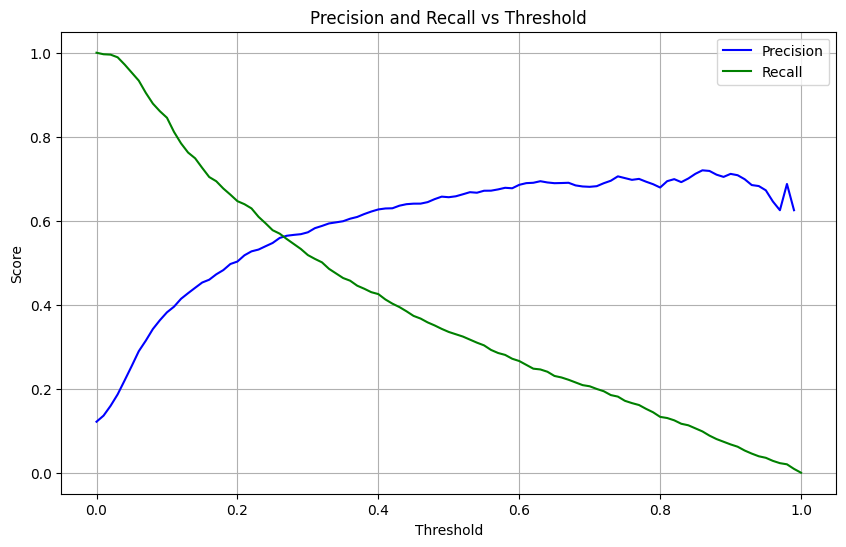

In [15]:
from sklearn.metrics import accuracy_score, recall_score

precisions = []
recalls = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    precisions.append(p)

    r = tp / (tp + fn)
    recalls.append(r)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision", color="blue")
plt.plot(thresholds, recalls, label="Recall", color="green")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

Question 4. F1 score threshold

In [16]:
thresholds = np.linspace(0, 1, 101)

f1s = {}

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)

    r = tp / (tp + fn)

    f1 = 2 * ((p * r) / (p + r))
    f1s[str(t)] = (f1.round(3))

#f1s
[key for key, value in f1s.items() if value == max(f1s.values())]

C:\Users\sendd\AppData\Local\Temp\ipykernel_22864\373367666.py:18: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


['0.22']

## 4.7 Cross-Validation

Question 5. STD for 5-Fold CV

In [17]:
from sklearn.model_selection import KFold

def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear',C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [18]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.y.values
    y_val = df_val.y.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

np.std(scores)

0.005658436499910648

In [19]:
!pip install tqdm
from tqdm.auto import tqdm

## 4.8 Tunning

Question 6. Best C

In [20]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.y.values
        y_val = df_val.y.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    # + mean = better score, - std = less variability
    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.701 +- 0.009
C=0.001 0.861 +- 0.007
C=1 0.906 +- 0.006
